In [83]:
# Matrix Libraries
import pandas as pd
import numpy as np
import itertools

# Machine Learning Libraries
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, learning_curve
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, average_precision_score, roc_curve, auc, precision_score, recall_score
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

from scipy.stats import loguniform 

# Data Preprocessing Libraries
import missingno as msno

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Load the data
Td = pd.read_csv('TelecomCustomerChurn.csv')

# **Telecom Customer Churn Prediction**

## Introduction

In this project, we aim to predict customer churn for a telecom company. Customer churn refers to the phenomenon where customers stop using a company's services. Predicting churn is crucial for businesses as it helps them take proactive measures to retain customers and improve their services.

## Dataset

The dataset used in this project is the "Telecom Customer Churn" dataset. It contains information about 7043 customers, including their demographics, account information, and services they have subscribed to. The dataset has 21 columns, each representing a different feature of the customer.

### Features

- `customerID`: Unique identifier for each customer.
- `Gender`: Gender of the customer (Male/Female).
- `SeniorCitizen`: Indicates if the customer is a senior citizen (1) or not (0).
- `Partner`: Indicates if the customer has a partner (Yes/No).
- `Dependents`: Indicates if the customer has dependents (Yes/No).
- `Tenure`: Number of months the customer has stayed with the company.
- `PhoneService`: Indicates if the customer has phone service (Yes/No).
- `MultipleLines`: Indicates if the customer has multiple lines (Yes/No).
- `InternetService`: Type of internet service the customer has (DSL/Fiber optic/No).
- `OnlineSecurity`: Indicates if the customer has online security service (Yes/No).
- `OnlineBackup`: Indicates if the customer has online backup service (Yes/No).
- `DeviceProtection`: Indicates if the customer has device protection service (Yes/No).
- `TechSupport`: Indicates if the customer has tech support service (Yes/No).
- `StreamingTV`: Indicates if the customer has streaming TV service (Yes/No).
- `StreamingMovies`: Indicates if the customer has streaming movies service (Yes/No).
- `Contract`: Type of contract the customer has (Month-to-month/One year/Two year).
- `PaperlessBilling`: Indicates if the customer has paperless billing (Yes/No).
- `PaymentMethod`: Payment method used by the customer (Electronic check/Mailed check/Bank transfer/Credit card).
- `MonthlyCharges`: The amount charged to the customer monthly.
- `TotalCharges`: The total amount charged to the customer.
- `Churn`: Indicates if the customer has churned (Yes/No).

The target variable in this dataset is `Churn`, which we aim to predict using the other features.

## Objective

The objective of this project is to build a machine learning model that can accurately predict whether a customer will churn or not based on their features. This will help the telecom company identify at-risk customers and take necessary actions to retain them.

---

# Data Visualization

In [3]:
Td

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


In [4]:
Td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


First thing to do is to modify the target column **Churn** with a <code>LableEncoder</code> so that we have numerical values as targets.

In [5]:
le = LabelEncoder()
Td['Churn'] = le.fit_transform(Td['Churn'])

There appear to be no missing values in the dataset based on the `info()` output. However, there's need to investigate further as there might be features with 'NaN' values represented as strings. Additionally, we need to convert the `TotalCharges` column to the `float64` data type for accurate analysis.

In [6]:
for col in Td.columns:
    print(col+':', Td[col].unique())
    print('-'*50)

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
Gender: ['Female' 'Male']
--------------------------------------------------
SeniorCitizen: [0 1]
--------------------------------------------------
Partner: ['Yes' 'No']
--------------------------------------------------
Dependents: ['No' 'Yes']
--------------------------------------------------
Tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService: ['No' 'Yes']
--------------------------------------------------
MultipleLines: ['No' 'Yes']
--------------------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: ['N

In [7]:
Td = Td.drop(columns=['customerID'])
# We will drop the customerID column as it is not useful for our analysis

Last remaing thing to do is convert the <code>TotalCharges</code> column into <code>float64</code>.

In [8]:
# Convert missing values coded as ' ' to '0.0' and convert the column to float
Td['TotalCharges'] = Td['TotalCharges'].replace(' ', '0.0')
Td['TotalCharges'] = Td['TotalCharges'].astype(float)

In [9]:
# Check for missing values coded as ' '
Td[Td ==' '].count()

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now it's sure that there are no missing values in our dataset.

### Noise Adding

To better simulate real world experience I will use functions published by the professor to add noise to the dataset.

In [10]:
def add_missing(col, amount):
    X = col.copy()
    size = amount if amount >= 1 else int(len(X) * amount)
    indexes = np.random.choice(len(X), size, replace = False )
    X[indexes] = np.nan
    return X


In [11]:
# Add missing values to some columns
noise_col = ['Gender', 'Partner', 'Tenure', 'MultipleLines', 'InternetService', 'OnlineBackup', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

for col in noise_col:
    if col == 'Gender':
        Td[col] = add_missing(Td[col], 0.5)
    Td[col] = add_missing(Td[col], 0.1)


In [12]:
Td.isnull().sum(axis=0)/Td.shape[0]

Gender              0.550618
SeniorCitizen       0.000000
Partner             0.099957
Dependents          0.000000
Tenure              0.099957
PhoneService        0.000000
MultipleLines       0.099957
InternetService     0.099957
OnlineSecurity      0.000000
OnlineBackup        0.099957
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.099957
PaymentMethod       0.099957
MonthlyCharges      0.099957
TotalCharges        0.099957
Churn               0.000000
dtype: float64

Another way of visualizing missing data is through the <code>missingno</code> library.

<Axes: >

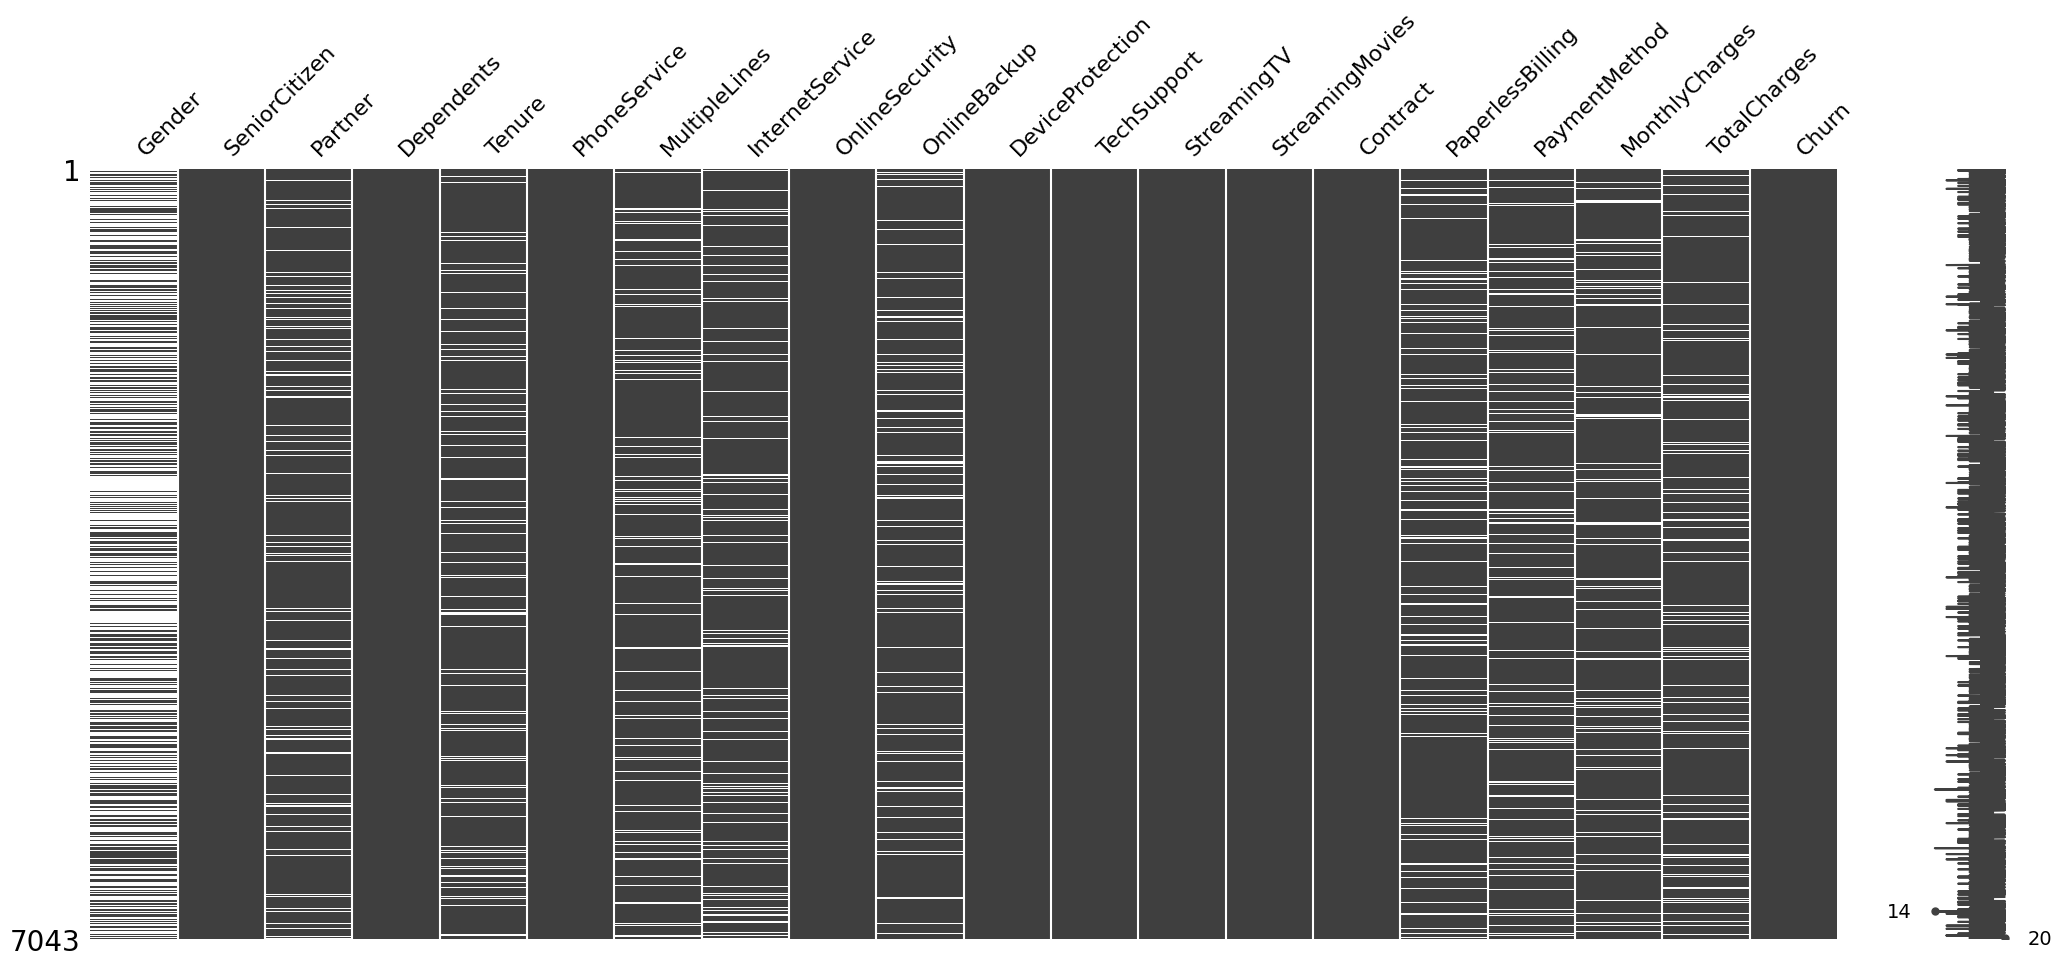

In [13]:
msno.matrix(Td)

# Data Transformation Pipeline

Now that a clear visualization of the dataset in its entirety is found, it's time to define the different pipelines of work that I will apply after the splitting.

### Pipeline1

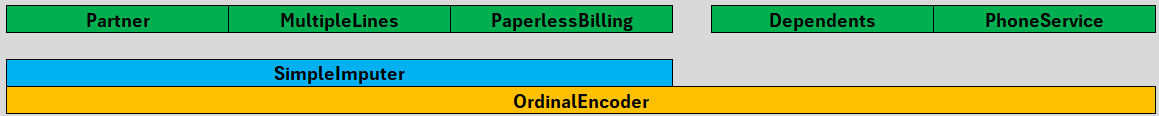

I will address the missing values in the columns: **Partner**, **MultipleLines**, and **PaperlessBilling** using the <code>SimpleImputer</code> from the *Sklearn* library. After imputing the missing values, I will encode the categorical values in these columns with the <code>OrdinalEncoder</code> from the *Sklearn* library.

### Pipeline2

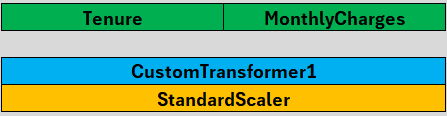

I will address the missing values in the columns **Tenure** and **MonthlyCharges** with a custom transformer and then scale the resulting values with the <code>StandardScaler</code> from the Sklearn library.

### Pipeline3

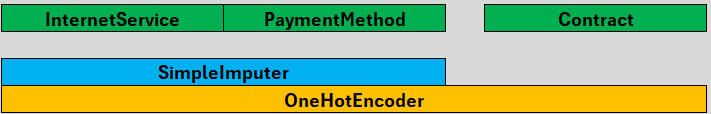

I will address the missing values in the column **InternetService** and **PaymentMethod** with the <code>SimpleImputer</code> from the Sklearn library. Then for all the columns showed I will use the **OneHotEncoder** to map each categorical feature of the column.

### Pipeline4

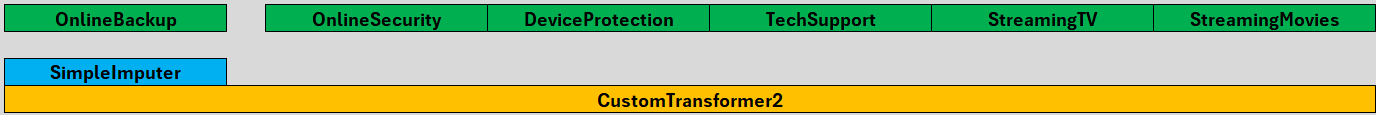

For the last pipeline, I will handle missing values in the **OnlineBackup** column using a <code>SimpleImputer</code>. To reduce complexity and create a more readable dataset, I will combine six columns into one that represents the number of extraservices of the customer and add this column to the dataset to increase the dimensionality.

___

The **Gender** column will be dropped due to high percentage of missing values.  
The **TotalCharges** column will be dropped since it's a linear combination of two other columns.  
The **SeniorCitizen** column is not present in any pipeline cause it was already in a good format.  

In [14]:
Td.drop(columns=['Gender'], inplace=True)

### Custom Transformers

The first custom transformer will deal with missing values in the **Tenure** and **MonthlyCharges** columns using the linear relationship that can be found between **Tenure**,**MonthlyCharges** and **TotalCharges**. $$\text{Tenure} = {\text{TotalCharges}\over\text{MonthlyCharges}}$$ After it will drop the **TotalCharges** column to avoid multicollinaerity.

In [15]:
class CustomTransformer1(BaseEstimator, TransformerMixin):
    def __init__(self, tenure_col="Tenure", monthly_col="MonthlyCharges", total_col="TotalCharges"):
        self.tenure_col = tenure_col
        self.monthly_col = monthly_col
        self.total_col = total_col

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):

        ## Fill missing values in the tenure column
        mask = X[self.tenure_col].isna()
        X.loc[mask, self.tenure_col] = (X[self.total_col] / X[self.monthly_col])

        ## Fill missing values in the monthly charges column
        mask = X[self.monthly_col].isna()
        X.loc[mask, self.monthly_col] = (X[self.total_col] / X[self.tenure_col])

        ## Convert Tenure to integer for easier manipulation
        X[self.tenure_col] = X[self.tenure_col].astype(int)

        ## Convert MonthlyCharges to two point decimal
        X[self.monthly_col] = X[self.monthly_col].round(2)

        ## Drop the TotalCharges column since it's a linear combination of Tenure and MonthlyCharges
        X = X.drop(columns=[self.total_col])

        return X



The second custom transformer will combine togheter the: **OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies** columns, in a single one, that will represent the number of services each customer has.

In [16]:
class CustomTransformer2(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        ## Create the ExtraServices column and assign the values of the sum of the other columns
        Y = (X == 'Yes').sum(axis=1)

        ## Apply the MinMaxScaler to the Y column
        minmax_scaler = MinMaxScaler()
        Y = minmax_scaler.fit_transform(Y.reshape(-1, 1))

        ## Apply the ordinal encoding to the original columns
        ordinal_enc = OrdinalEncoder()
        X = ordinal_enc.fit_transform(X)   

        X_transformed = np.hstack((X, Y))     
                
        return X_transformed




___

The last thing we have to do before creating the pipelines and the **ColumnTransformer** is to drop some problematic rows that could mess with the custom transformers:
- Drop rows where more than 1 value between **Tenure**, **MonthlyCharges**, **TotalCharges** are <code>NaN</code>
- Drop rows where **MonthlyCharges** has value *zero*
- Drop rows where **MonthlyCharges** value is missing and **Tenure** has value zero

In [17]:
## Create the first mask to detect rows where at least 2 of the values of columns Tenure, MonthlyCharges and TotalCharges are missing
mask_1 = (Td[['Tenure', 'MonthlyCharges', 'TotalCharges']].isna().sum(axis=1) >= 2)
Td.drop(index=Td[mask_1].index, inplace=True)

## Create the second mask to detect rows where MonthlyCharges or Tenure have value zero
mask_2 = Td['MonthlyCharges'] == 0
Td.drop(index=Td[mask_2].index, inplace=True)

## Create the third mask to detect rows where MonthlyCharges is NaN and Tenure is zero
mask_3 = Td['MonthlyCharges'].isna() & (Td['Tenure'] == 0)
Td.drop(index=Td[mask_3].index, inplace=True)

In [18]:
pipeline1 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('lable', OrdinalEncoder())
])

pipeline2 = Pipeline([
    ('custom1', CustomTransformer1()),
    ('scaler', StandardScaler())
])

pipeline3 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

pipeline4 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('custom2', CustomTransformer2())  
])

final_transformer = ColumnTransformer(transformers=[
    ('pipeline1', pipeline1, ['Partner', 'MultipleLines', 'PaperlessBilling', 'Dependents', 'PhoneService']),
    ('pipeline2', pipeline2, ['Tenure', 'MonthlyCharges', 'TotalCharges']),
    ('pipeline3', pipeline3, ['InternetService', 'PaymentMethod', 'Contract']),
    ('pipeline4', pipeline4, ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'])
],
remainder = 'passthrough',
verbose_feature_names_out = False,
sparse_threshold = 0
)

# Train & Test split

Now that the <code>final_transformer</code> has been defined I Have to split the dataset into **Train** and **Test**.

In [20]:
## Define the target variable
y = Td['Churn']

## Define the features
X = Td.drop(columns=['Churn'])

## Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We now define the starting pipeline

In [21]:
pip = ImbPipeline([
    ('transformer', final_transformer),
    ('sampler', SMOTE()),
    ('dim_reduction', PCA()),
    ('classifier', Perceptron())
])

In [22]:
pip.fit(X_train, y_train)

  File "C:\Users\robyt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('pipeline1',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('lable',
                                                                   OrdinalEncoder())]),
                                                  ['Partner', 'MultipleLines',
                                                   'PaperlessBilling',
                                                   'Dependents',
                                                   'PhoneService']),
                                                 ('pipeline2',
                                                  Pipeline(steps=[('custom1',
                                                                   CustomTransformer1()),...
                                                  ['InternetService',
                                                   'PaymentMethod',
                                                   'Contract']),
                                                 ('pipeline4',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('custom2',
                                                                   CustomTransformer2())]),
                                                  ['OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies'])],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE()), ('dim_reduction', PCA()),
                ('classifier', Perceptron())])

# Model Selection

We define all the elements needed for the search of the best possible model. The final output will be a list of 5 piplines consisting of:
- **final_transformer**
- **dimensionality reduction**
- handling of **imbalanced classes**
- **classification**

The following are the models and configurations we will use:
- For Sampling, we'll try to use SMOTE (Synthetic Minority Over-sampling Technique) and a RandomOverSampler.
- For Dimensionality Reduction we will try to use PCA, LDA and SequentialFeatureSelector that uses Perceptron or LogisticRegression as estimators.
- For classifiers, we'll try different configurations of Perceptron, LogisticRegression, KNeighbors, RandomForest, SVC, XGBoost and GradientBoostingClassifier.

In [43]:
sampler_configs = [
    {
        'sampler':[None] # The element is bypassed
    },
    {
        'sampler':[SMOTE()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None] # The element is bypassed
    },
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.5, 0.7, 0.9]
    },
    {
        'dim_reduction': [LDA()]
    },
    {
        'dim_reduction': [SFS(estimator=Perceptron(), cv = None, scoring = 'f1')],
        'dim_reduction__estimator': [Perceptron(), LogisticRegression()],
        'dim_reduction__k_features' : [5,7,10]
    }
]

classifier_configs = [
    {
        'classifier__eta0' : loguniform(0.001,100),
        'classifier': [Perceptron()] ,
        'classifier__max_iter': [1,5,10,15,50,100] ,
        'classifier__class_weight' : [None, 'balanced']

    },
    {
        'classifier': [LogisticRegression(solver='saga')],
        'classifier__C' : loguniform(1e-2, 1e1),
        'classifier__penalty': ['l1','l2'],
        'classifier__class_weight' : [None, 'balanced']

    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [1,3,5,7,9]
    },
    {
        'classifier' : [RandomForestClassifier()],
        'classifier__n_estimators' : [10, 25, 50, 100, 125]
    },
    {
        'classifier': [SVC()],
        'classifier__C': loguniform(1e-2, 1e1),
        'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'classifier__gamma': loguniform(1e-4, 1),
        'classifier__class_weight': [None, 'balanced'],
    },
    {
        'classifier': [XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.7, 0.8, 1.0]
    },
    {
        'classifier': [GradientBoostingClassifier()],
        'classifier__n_estimators': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.7, 0.8, 1.0],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['auto', 'sqrt', 'log2', None],
        'classifier__loss': ['deviance', 'exponential']
    },
    {
        'classifier': [CatBoostClassifier(logging_level='Silent')],
        'classifier__iterations': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__depth': [3, 6, 9],
        'classifier__bootstrap_type': ['Bayesian', 'Bernoulli', 'MVS', 'Poisson', 'No']
    }
]

Now using the **product** of the <code>itertools</code> module, we can enumerate all the possible configuration of this elements.

In [24]:
all_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

In [25]:
print('Total number of configurations:', len(all_configs))

Total number of configurations: 96


We will now use **nested cross-validation** to find the best pipeline out of the 96 possible configuration we created using <code>itertools</code>. We do so with <code>RandomizedSearchCV</code> which implements the inner loop of **cross-validation**.

In [30]:
rs = RandomizedSearchCV(pip,
    param_distributions=all_configs,
    n_iter=len(all_configs) * 10,
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

We now use <code>cross_validate</code> to perform the outer loop of the **cross-validation** and find the best models according to the *f1* scoring sistem.

In [31]:
scores = cross_validate(rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time= 2.6min
[CV] END .................................................... total time= 2.2min
[CV] END .................................................... total time= 4.6min
[CV] END .................................................... total time= 2.3min
[CV] END .................................................... total time= 2.4min


Now with a for loop, we print the five best models.

In [32]:
for index, estimator in enumerate(scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy='minority')
LinearDiscriminantAnalysis()
<catboost.core.CatBoostClassifier object at 0x0000022315D03B00> {'logging_level': 'Silent', 'bootstrap_type': 'No', 'depth': 9, 'iterations': 300, 'learning_rate': 0.014423011076779504}
0.6215139442231076
----------
RandomOverSampler(sampling_strategy=0.7)
None
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.022147189632134155, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,


To get an even better understanding of the actual performance of the model we re-train the models on the *train-set* and then evaluate their performance on the *test-set*.

In [33]:
for estimator in scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6301292861157954, F1 on test set:0.6212765957446809
F1 on training set:0.6337986337986338, F1 on test set:0.6280417149478563
F1 on training set:0.6789250353606789, F1 on test set:0.6301969365426696
F1 on training set:0.6364444444444445, F1 on test set:0.6285046728971962
F1 on training set:0.6313441160066927, F1 on test set:0.6240681576144835


We are gonna re-run the **cross-validation** using only <code>CatBoost</code> and <code>XGBClassifier</code> to see which one performes best.

In [34]:
classifier_configs = [
    {
        'classifier': [XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.7, 0.8, 1.0]
    },
    {
        'classifier': [CatBoostClassifier(logging_level='Silent')],
        'classifier__iterations': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__depth': [3, 6, 9],
        'classifier__bootstrap_type': ['Bayesian', 'Bernoulli', 'MVS', 'Poisson', 'No']
    }
]

In [35]:
all_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(all_configs))

Total number of configurations: 24


In [38]:
## INNER LOOP
rs1 = RandomizedSearchCV(pip,
    param_distributions=all_configs,
    n_iter=len(all_configs) * 20,
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
scores1 = cross_validate(rs1, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time= 1.1min
[CV] END .................................................... total time= 1.1min
[CV] END .................................................... total time=  60.0s
[CV] END .................................................... total time= 1.0min
[CV] END .................................................... total time= 1.2min


In [39]:
for index, estimator in enumerate(scores1['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores1['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy=0.9)
LinearDiscriminantAnalysis()
<catboost.core.CatBoostClassifier object at 0x000002231E1F1850> {'logging_level': 'Silent', 'bootstrap_type': 'Bernoulli', 'depth': 3, 'iterations': 150, 'learning_rate': 0.02819629273699719}
0.6395511921458625
----------
SMOTE(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x0000022315BD1850> {'logging_level': 'Silent', 'bootstrap_type': 'Bernoulli', 'depth': 6, 'iterations': 200, 'learning_rate': 0.01846935686831503}
0.6416275430359938
----------
RandomOverSampler(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x000002231F1BCD70> {'logging_level': 'Silent', 'bootstrap_type': 'No', 'depth': 6, 'iterations': 200, 'learning_rate': 0.01509771300665941}
0.6008462623413258
----------
SMOTE(sampling_strategy=0.9)
LinearDiscriminantAnalysis()
<catboost.core.CatBoostClassifier object at 0x0000022315CE2BA0> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3,

We can clearly see that <code>CatBoost</code> is the better option so we will from now on procede with that classifier.

In [40]:
for estimator in scores1['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6295045045045045, F1 on test set:0.6227417640807651
F1 on training set:0.6462192529608259, F1 on test set:0.6261904761904762
F1 on training set:0.6513966480446928, F1 on test set:0.6295503211991434
F1 on training set:0.6288659793814433, F1 on test set:0.616557734204793
F1 on training set:0.628668171557562, F1 on test set:0.6153846153846154


The best performing pipeline is the *third*, so we will use it as the starting pipeline for the **hyperparameter optimization**.

## HyperParameter Optimization

Since we have established which the best model is, we can run once again a **nested cross-validation** in order to have the best ranges og hyperparameters and the best combiantions of sampling and dimensionality reduction tools.

In [41]:
best_pip = ImbPipeline([
    ('transformer', final_transformer),
    ('sampler', RandomOverSampler()),
    ('dim_reduction', [None]),
    ('classifier', CatBoostClassifier())
])

In [44]:
classifier_configs = [
    {
        'classifier': [CatBoostClassifier(logging_level='Silent')],
        'classifier__iterations': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__depth': [3, 6, 9],
        'classifier__bootstrap_type': ['Bayesian', 'Bernoulli', 'MVS', 'Poisson', 'No']
    }
]

In [45]:
best_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(best_configs))

Total number of configurations: 12


We now run **nested cross-validation** on this set of possible configuration.

In [47]:
## INNER LOOP
best_rs = RandomizedSearchCV(best_pip,
    param_distributions=best_configs,
    n_iter=len(best_configs) * 50, ## Increase the number of iterations for optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
best_scores = cross_validate(best_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time= 1.7min
[CV] END .................................................... total time= 2.0min
[CV] END .................................................... total time= 2.3min
[CV] END .................................................... total time= 2.6min
[CV] END .................................................... total time= 2.3min


And run again the procedure to get the 5 best models out.

In [48]:
for index, estimator in enumerate(best_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(best_scores['test_score'][index])
    print('-'*10)

SMOTE(sampling_strategy=0.9)
LinearDiscriminantAnalysis()
<catboost.core.CatBoostClassifier object at 0x0000022302D5CEF0> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3, 'iterations': 200, 'learning_rate': 0.013364561792951696}
0.6334716459197787
----------
SMOTE(sampling_strategy=0.9)
LinearDiscriminantAnalysis()
<catboost.core.CatBoostClassifier object at 0x0000022315C527B0> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 9, 'iterations': 200, 'learning_rate': 0.011903524525833526}
0.6351550960118169
----------
RandomOverSampler(sampling_strategy=0.9)
LinearDiscriminantAnalysis()
<catboost.core.CatBoostClassifier object at 0x0000022315C52900> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3, 'iterations': 300, 'learning_rate': 0.021795062188493385}
0.6176046176046176
----------
RandomOverSampler(sampling_strategy=0.7)
None
<catboost.core.CatBoostClassifier object at 0x00000223157E2900> {'logging_level': 'Silent', 'bootstrap

In [49]:
for estimator in best_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6290509259259259, F1 on test set:0.6233480176211453
F1 on training set:0.6304347826086957, F1 on test set:0.6130434782608696
F1 on training set:0.6302068574667045, F1 on test set:0.628755364806867
F1 on training set:0.645081714461918, F1 on test set:0.6240963855421687
F1 on training set:0.6301056840902599, F1 on test set:0.6210640608034745


We can further select the best configuration:
- The best sampler is still unclear
- The best dimensionality reduction is either <code>LDA</code> or <code>None</code>  


As for the hyperparameters of <code>XGBClassifier</code> we will try all that appeared on the last search and also explore in more detail the ranges.

In [52]:
sampler_configs = [
    {
        'sampler':[SMOTE()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    },
    {
        'dim_reduction': [LDA()]
    }
]

classifier_configs = [
    {
        'classifier': [CatBoostClassifier(logging_level='Silent')],
        'classifier__iterations': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__depth': [3, 6, 9],
        'classifier__bootstrap_type': ['Bayesian']
    }
]

In [53]:
evenbetter_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(evenbetter_configs))

Total number of configurations: 4


In [54]:
## INNER LOOP
evenbetter_rs = RandomizedSearchCV(best_pip,
    param_distributions=evenbetter_configs,
    n_iter=len(evenbetter_configs) * 50, ## Increase the number of iterations for optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
evenbetter_scores = cross_validate(evenbetter_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=  48.8s
[CV] END .................................................... total time=  47.0s
[CV] END .................................................... total time= 1.1min
[CV] END .................................................... total time=  54.9s
[CV] END .................................................... total time=  49.3s


Further analyze this models to find the final and best one.

In [55]:
for index, estimator in enumerate(evenbetter_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(evenbetter_scores['test_score'][index])
    print('-'*10)

SMOTE(sampling_strategy='minority')
LinearDiscriminantAnalysis()
<catboost.core.CatBoostClassifier object at 0x0000022315C41430> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 9, 'iterations': 150, 'learning_rate': 0.018788088457344004}
0.6336088154269972
----------
RandomOverSampler(sampling_strategy=0.7)
None
<catboost.core.CatBoostClassifier object at 0x0000022302CA1940> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 6, 'iterations': 150, 'learning_rate': 0.01535922221898435}
0.6324237560192616
----------
RandomOverSampler(sampling_strategy=0.7)
None
<catboost.core.CatBoostClassifier object at 0x00000223094F36B0> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 9, 'iterations': 200, 'learning_rate': 0.012115464228470279}
0.6057692307692307
----------
RandomOverSampler(sampling_strategy=0.7)
None
<catboost.core.CatBoostClassifier object at 0x000002231E03C200> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3

In [56]:
for estimator in evenbetter_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6303740926856505, F1 on test set:0.6109936575052854
F1 on training set:0.6493262300219367, F1 on test set:0.6285018270401949
F1 on training set:0.7074015748031496, F1 on test set:0.6257822277847309
F1 on training set:0.6358346094946401, F1 on test set:0.6410564225690276
F1 on training set:0.6301447629860913, F1 on test set:0.6105717367853291


We can see that the best model is the third, and it uses:
- **Sampler** = <code>RandomOverSapler</code> with sampling strategy *0.7*
- **Dim_reduction** = <code>None</code>


In [58]:
sampler_configs = [
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 0.9, 0.7] ## Limit the sampling strategy to the one that performed best
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    }
]

classifier_configs = [
    {    
        'classifier': [CatBoostClassifier(logging_level='Silent')],
        'classifier__iterations': [100, 150, 200, 250, 300, 350 ,400], ## Increase the number of iterations
        'classifier__learning_rate': loguniform(0.01, 0.04),
        'classifier__depth': [3, 6, 9],
        'classifier__bootstrap_type': ['Bayesian']
    }   
]

In [59]:
final_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(final_configs))

Total number of configurations: 1


In [60]:
## INNER LOOP
final_rs = RandomizedSearchCV(best_pip,
    param_distributions=final_configs,
    n_iter=len(final_configs) * 50, ## Increase the number of iterations by a lot for the final optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
final_scores = cross_validate(final_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=  33.6s
[CV] END .................................................... total time=  41.7s
[CV] END .................................................... total time=  33.6s
[CV] END .................................................... total time=  30.8s
[CV] END .................................................... total time=  33.1s


Let's visualize these last results.

In [61]:
for index, estimator in enumerate(final_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(final_scores['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x0000022315CF9CD0> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 6, 'iterations': 250, 'learning_rate': 0.014858692103403}
0.6434540389972145
----------
RandomOverSampler(sampling_strategy=0.7)
None
<catboost.core.CatBoostClassifier object at 0x00000223094E4530> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3, 'iterations': 100, 'learning_rate': 0.03414795372018589}
0.6363636363636364
----------
RandomOverSampler(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x0000022302C61C10> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3, 'iterations': 400, 'learning_rate': 0.014479696322916676}
0.6120218579234973
----------
RandomOverSampler(sampling_strategy=0.7)
None
<catboost.core.CatBoostClassifier object at 0x0000022315D03470> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3, 'iterations': 350, '

In [62]:
for estimator in final_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6552209400506614, F1 on test set:0.6340933767643865
F1 on training set:0.6376988984088128, F1 on test set:0.6242496998799519
F1 on training set:0.6387959866220736, F1 on test set:0.630901287553648
F1 on training set:0.6346153846153846, F1 on test set:0.6365853658536585
F1 on training set:0.6396495071193866, F1 on test set:0.63125


The best model seems to be:
- **Sampler** = <code>RandomOverSampler</code>, with sampling_strategy *0.9*
- **Dim_reduction** = <code>None</code>


I will run a last **cross-validation**.

In [63]:
sampler_configs = [
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':[0.9] 
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    }
]

classifier_configs = [
    {
        'classifier': [CatBoostClassifier(logging_level='Silent')],
        'classifier__iterations': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__depth': [3, 6, 9],
        'classifier__bootstrap_type': ['Bayesian']
    }
]

In [64]:
definetlylast_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(definetlylast_configs))

Total number of configurations: 1


In [65]:
## INNER LOOP
definetlylast_rs = RandomizedSearchCV(best_pip,
    param_distributions=definetlylast_configs,
    n_iter=len(definetlylast_configs) * 100, ## Increase the number of iterations by a lot for the final optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
definitelylast_scores = cross_validate(definetlylast_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=  50.9s
[CV] END .................................................... total time=  51.9s
[CV] END .................................................... total time=  55.5s
[CV] END .................................................... total time=  50.0s
[CV] END .................................................... total time=  57.0s


In [66]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(definitelylast_scores['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x000002231F6A1850> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 6, 'iterations': 200, 'learning_rate': 0.02333049740664398}
0.6312769010043041
----------
RandomOverSampler(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x0000022315C40200> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 9, 'iterations': 100, 'learning_rate': 0.010601869818736759}
0.6437125748502994
----------
RandomOverSampler(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x0000022302658C50> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 9, 'iterations': 200, 'learning_rate': 0.012812080475698512}
0.5961820851688693
----------
RandomOverSampler(sampling_strategy=0.9)
None
<catboost.core.CatBoostClassifier object at 0x0000022315A40B30> {'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 3, 'iterations': 300

In [67]:
for estimator in definitelylast_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6634858265506596, F1 on test set:0.6386192017259978
F1 on training set:0.6734177215189874, F1 on test set:0.6403508771929824
F1 on training set:0.7115329306873742, F1 on test set:0.6272321428571429
F1 on training set:0.6374172185430463, F1 on test set:0.630901287553648
F1 on training set:0.6514603616133519, F1 on test set:0.6346153846153846


In [88]:
for estimator in definitelylast_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    precision_train = precision_score(y_train, pred_train)
    precision_test = precision_score(y_test, pred_test)
    print(f'Precision on training set:{precision_train}, Precision on test set:{precision_test}')

Precision on training set:0.5637325637325638, Precision on test set:0.5242369838420108
Precision on training set:0.5663167938931297, Precision on test set:0.536178107606679
Precision on training set:0.6135, Precision on test set:0.5316698656429942
Precision on training set:0.5263876251137397, Precision on test set:0.5076660988074957
Precision on training set:0.5479323308270677, Precision on test set:0.5176678445229682


In [89]:
for estimator in definitelylast_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    recall_train = recall_score(y_train, pred_train)
    recall_test = recall_score(y_test, pred_test)
    print(f'F1 on training set:{recall_train}, F1 on test set:{recall_test}')

F1 on training set:0.8004129387474191, F1 on test set:0.7747252747252747
F1 on training set:0.8072952512044047, F1 on test set:0.7802197802197802
F1 on training set:0.8547832071576049, F1 on test set:0.7582417582417582
F1 on training set:0.8004129387474191, F1 on test set:0.8186813186813187
F1 on training set:0.7962835512732278, F1 on test set:0.804945054945055


All of the models have similar performances so we can look at:
- Confusion Matrix
- precision-recall Curve
- ROC curve

### Graphs

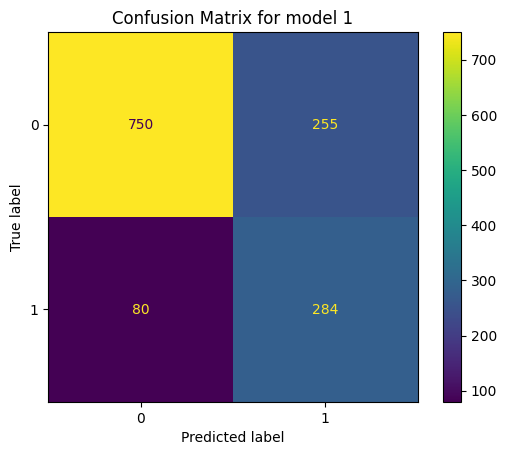

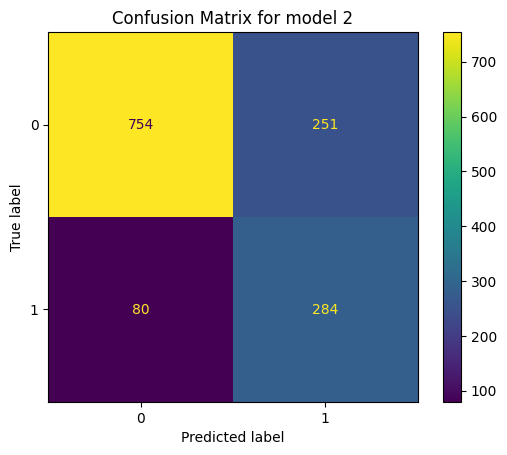

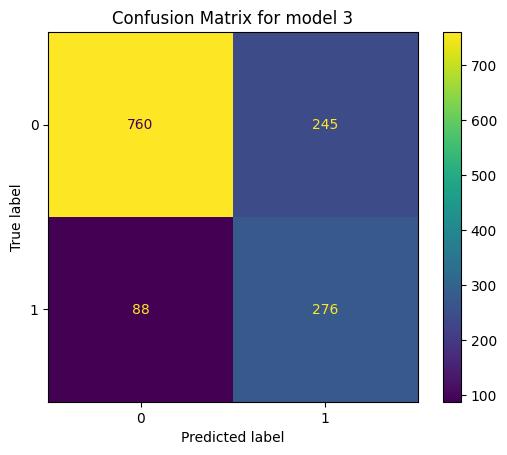

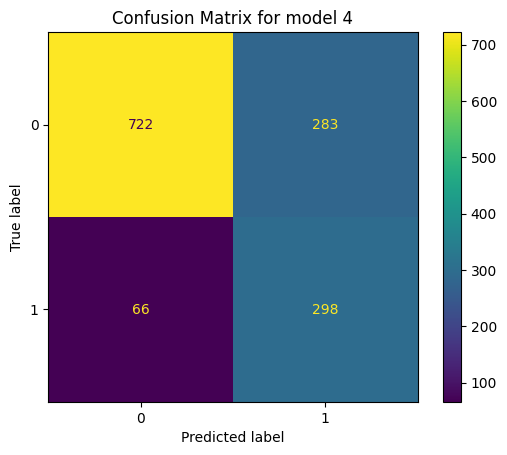

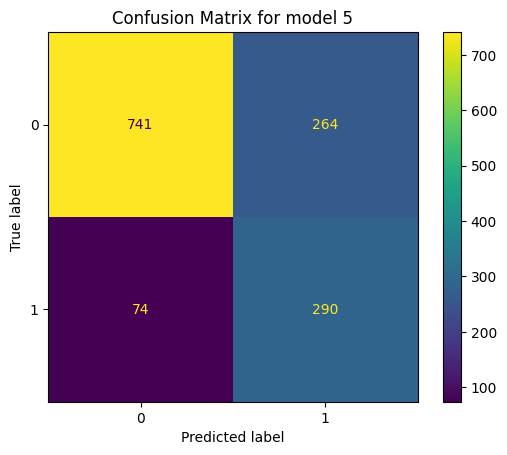

In [70]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    best_model = estimator.best_estimator_
    best_model.fit(X_train, y_train)
    predictions = best_model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix for model {index+1}')
    plt.show()

___

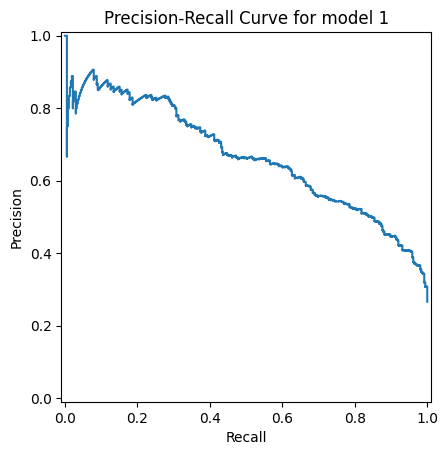

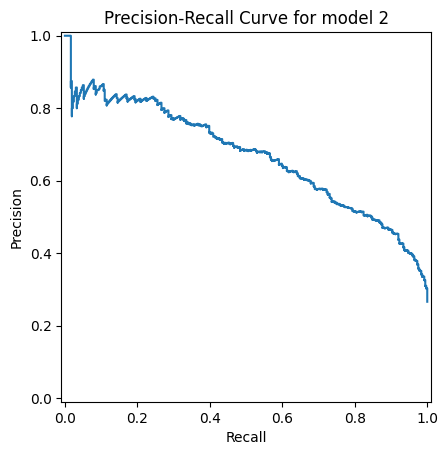

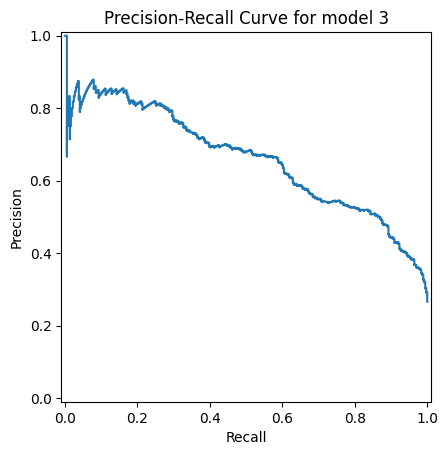

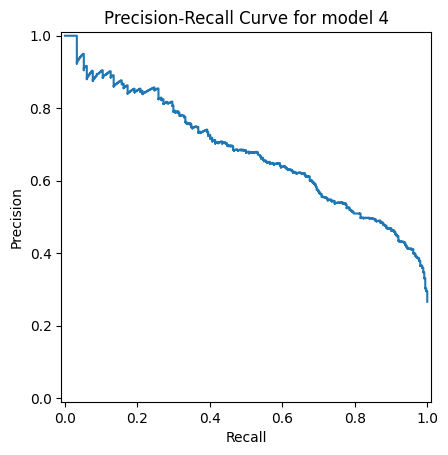

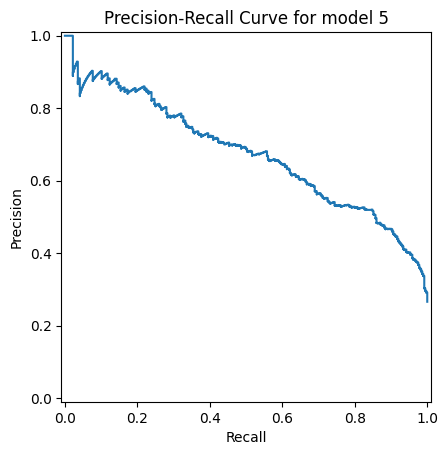

In [71]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    best_model = estimator.best_estimator_
    best_model.fit(X_train, y_train)  # Fit the model on training data
    pred_probs = best_model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, pred_probs)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot()
    plt.title(f'Precision-Recall Curve for model {index+1}')
    plt.show()

___


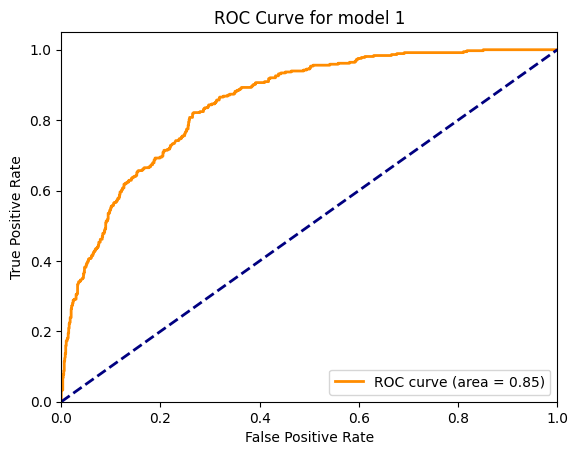

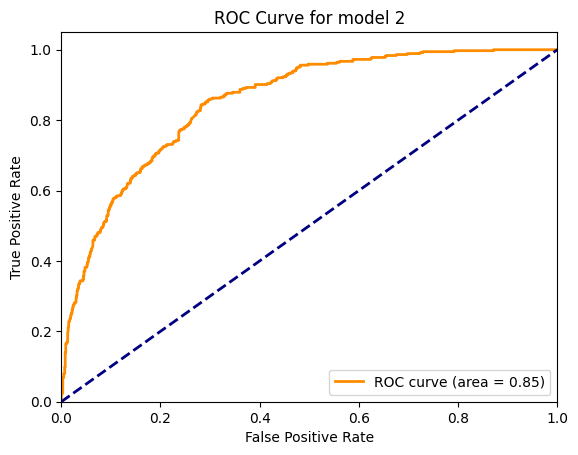

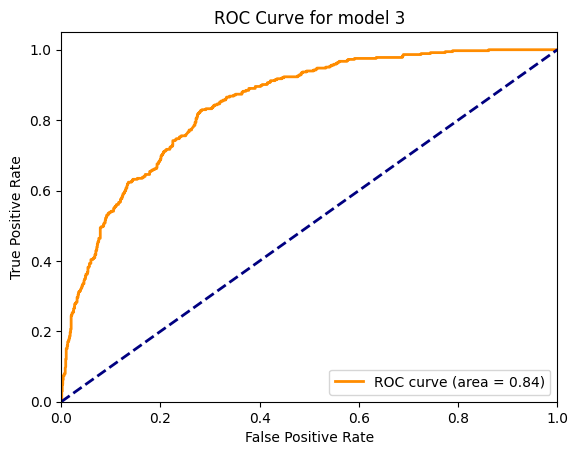

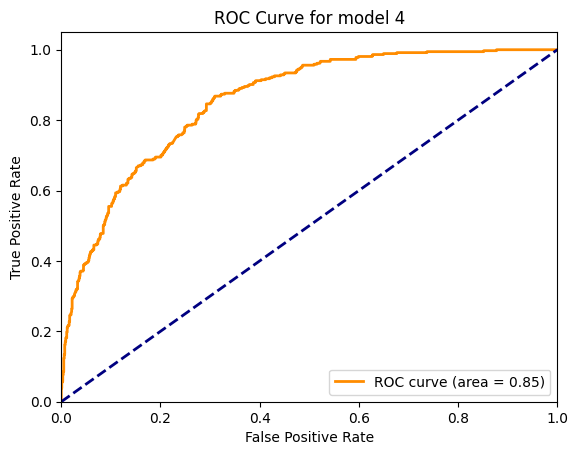

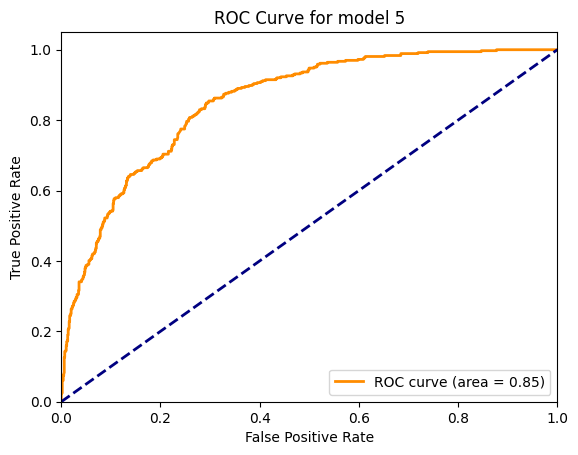

In [72]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    best_model = estimator.best_estimator_
    best_model.fit(X_train, y_train)  # Fit the model on training data
    pred_probs = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for model {index+1}')
    plt.legend(loc="lower right")
    plt.show()

The five models are all similar in terms of performance, but i will chose the second as the best.

## Best Model


In [96]:
best_model = definitelylast_scores['estimator'][1].best_estimator_
print(best_model['classifier'])
print(best_model['classifier'].get_params())

{'logging_level': 'Silent', 'bootstrap_type': 'Bayesian', 'depth': 9, 'iterations': 100, 'learning_rate': 0.010601869818736759}


### Learnign Curve

In [97]:
train_sizes, train_scores, test_scores = learning_curve(best_model,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = 5,
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle = False)

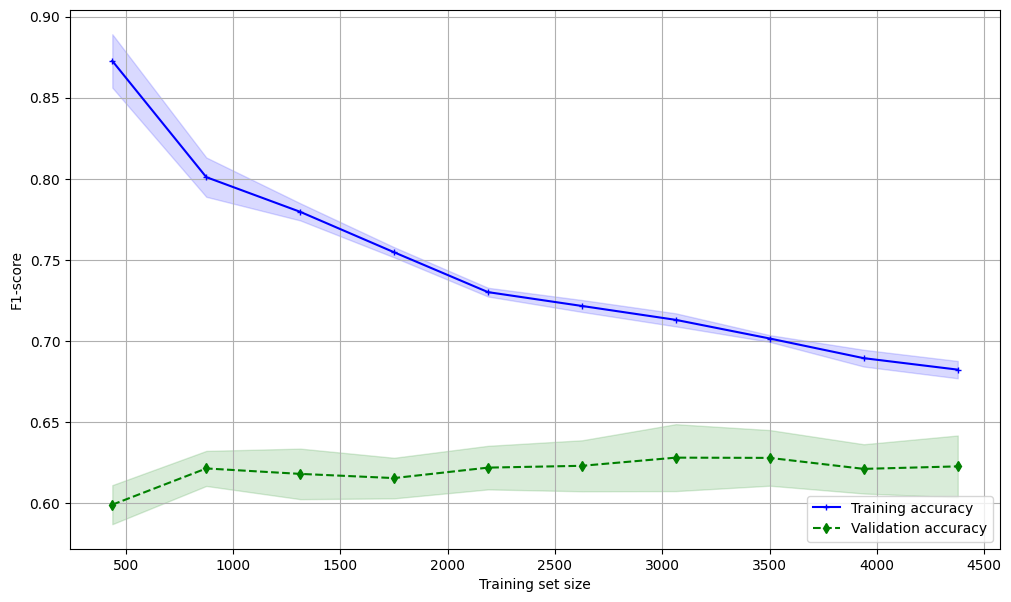

In [99]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training accuracy')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation accuracy')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')

In the end the final model is found.

In [100]:
best_model

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('pipeline1',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('lable',
                                                                   OrdinalEncoder())]),
                                                  ['Partner', 'MultipleLines',
                                                   'PaperlessBilling',
                                                   'Dependents',
                                                   'PhoneService']),
                                                 ('pipeline2',
                                                  Pipeline(steps=[('custom1',
                                                                   CustomTransformer1()),...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('custom2',
                                                                   CustomTransformer2())]),
                                                  ['OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies'])],
                                   verbose_feature_names_out=False)),
                ('sampler', RandomOverSampler(sampling_strategy=0.9)),
                ('dim_reduction', None),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x0000022315C40200>)])

In [101]:
best_model.score(X_test, y_test)

0.7560262965668371

In [102]:
precision_score(y_test, best_model.predict(X_test))

0.5278810408921933

In [103]:
recall_score(y_test, best_model.predict(X_test))

0.7802197802197802

In [104]:
f1_score(y_test, best_model.predict(X_test))

0.6297117516629712